<h1>Regresión Lineal - I</h1>

En un experimento de laboratorio se registra el crecimiento (en gramos) de una sustancia biológica durante varios días. Los datos observados son los siguientes:

- Realizar un gráfico de dispersión que permita visualizar la relación entre ambas variables.

- Ajustar un modelo de regresión lineal simple de la forma $Y=\beta_0+ \beta_1X$ donde $X$ representa los días e $Y$ representa los gramos.

- Determinar la ecuación estimada del modelo.

- Estimar:El valor esperado de gramos en el día 5 y el valor esperado de gramos en el día 15

- Calcular e interpretar
    - El error cuadrático medio.
    - El RMSE.
    - El coeficiente de determinación
      
- Analizar los residuos:
    - Realizar la representación gráfica.
    - Verificar la normalidad.
    - Verificar la homocedasticidad
 
- Construir el intervalo de confianza al 95% para verificar si la variable X es significativa.

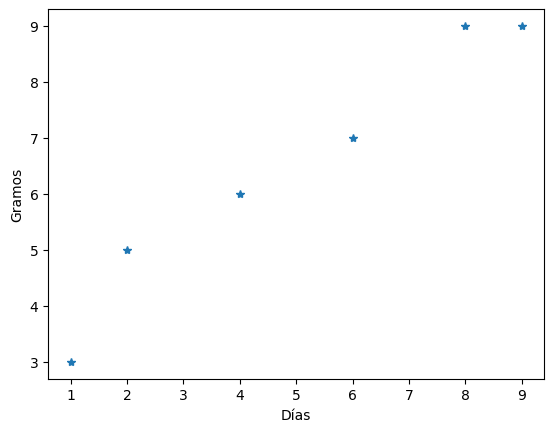

In [7]:
import numpy as np # Librería numérica
import matplotlib.pyplot as plt # Para crear gráficos con matplotlib
from sklearn.linear_model import LinearRegression # Regresión Lineal con scikit-learn

dias = np.array([1,2,4,6,8,9])
gramos = np.array([3,5,6,7,9,9])

plt.figure()
plt.plot(dias, gramos, '*')
plt.xlabel("Días")
plt.ylabel("Gramos")
plt.show()

In [8]:
regresion_lineal = LinearRegression() # creamos una instancia de LinearRegression

#Instruimos a la regresión lineal que aprenda de los datos (x, y)
regresion_lineal.fit(dias.reshape(-1, 1), gramos) 

# Se muestran los parámetros que ha estimado la regresión lineal
print("Coeficiente = %s, Intercerpto= %s" %(regresion_lineal.coef_, regresion_lineal.intercept_))

Coeficiente = [0.71153846], Intercerpto= 2.942307692307694


In [9]:
regresion_lineal.coef_ #la pendiente

array([0.71153846])

In [10]:
regresion_lineal.intercept_ #intercepto de la recta

np.float64(2.942307692307694)

In [11]:
print("y = %s+ %s x" %(regresion_lineal.intercept_, regresion_lineal.coef_))

y = 2.942307692307694+ [0.71153846] x


In [12]:
# vamos a predecir y = regresion_lineal(5)
nuevo_x = np.array([5]) 
prediccion = regresion_lineal.predict(nuevo_x.reshape(-1,1))
print("Número de gramos en el día 5: ", prediccion)

Número de gramos en el día 5:  [6.5]


In [13]:
# vamos a predecir y = regresion_lineal(15)
nuevo2_x= np.array([15])
prediccion2 = regresion_lineal.predict(nuevo2_x.reshape(-1,1))
print("Número de gramos en el día 15: ", prediccion2)

Número de gramos en el día 15:  [13.61538462]


In [14]:
# importamos el cálculo del error cuadrático medio (MSE)
from sklearn.metrics import mean_squared_error

# Predecimos los valores y para los datos usados en el entrenamiento
prediccion_entrenamiento = regresion_lineal.predict(dias.reshape(-1,1))

# Calculamos el Error Cuadrático Medio (MSE = Mean Squared Error)
mse = mean_squared_error(y_true = gramos, y_pred = prediccion_entrenamiento)

# La raíz cuadrada del MSE es el RMSE
rmse = np.sqrt(mse) #calcular raiz cuadrada
print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))

Error Cuadrático Medio (MSE) = 0.1955128205128205
Raíz del Error Cuadrático Medio (RMSE) = 0.44216831694821884


In [15]:
# calculamos el coeficiente de determinación R2
r2 = regresion_lineal.score(dias.reshape(-1,1), gramos) #coeficiente de determinación
print('Coeficiente de Determinación R2 = ' + str(r2))

Coeficiente de Determinación R2 = 0.9573426573426573


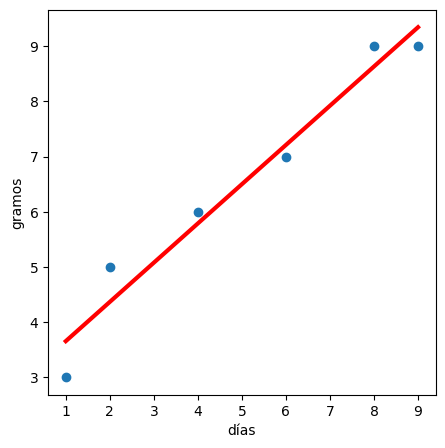

In [16]:
# Obtener valores modelo

# Representar x e y
fig = plt.figure(figsize=(5,5))
plt.scatter(dias, gramos)

x = dias.reshape(-1,1)

# Representar la recta de regresión
y_pred = regresion_lineal.predict(x)
plt.plot(x, y_pred, color='red', linewidth=3)

# Definir ejes
plt.xlabel("días")
plt.ylabel("gramos")

# Mostrar gráfico
plt.show()

In [17]:
# la recta debe pasar por el punto:
print("(", np.mean(dias), " ,", np.mean(gramos), ")")

( 5.0  , 6.5 )


In [18]:
# calcular sigma2
print("Varianza del modelo, s2: %.2f"% mean_squared_error(dias, y_pred))

Varianza del modelo, s2: 2.97


In [19]:
# estimador de la varianza por MLE (método de máxima verosimilitud)
y_resta = (gramos - y_pred) ** 2
sum(y_resta)/6

np.float64(0.1955128205128205)

In [20]:
# estimador de la varianza por OLS (mínimos cuadrados ordinarios)
y_resta = (gramos - y_pred) ** 2
sum(y_resta)/4 # 6-2

np.float64(0.2932692307692308)

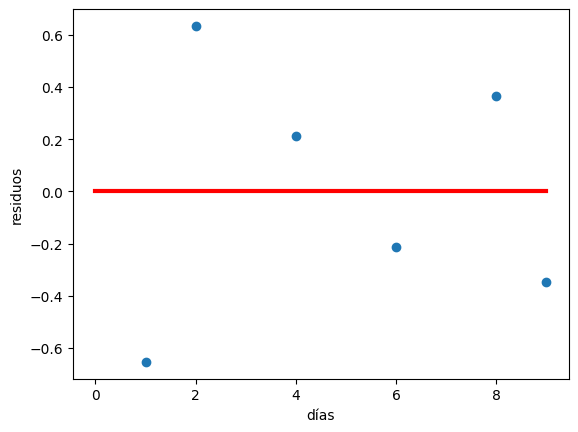

In [21]:
# obtener residuos
residuos = gramos - y_pred
plt.scatter(x, residuos)
plt.xlabel("días")
plt.ylabel("residuos")
plt.plot([0, np.max(x)], [0, 0], color = 'red', linewidth = 3)
plt.show()

In [22]:
import scipy.stats as stats

# se realiza la prueba S-W
sh_result = stats.shapiro(residuos)

# dar formato a la salida
print("Test Shapiro-Wilk, p.valor: %5.5f" %(sh_result.pvalue))
print("Como p.valor > 0.05, no se rechaza la hipótesis nula y se da normalidad en los residuos.")

Test Shapiro-Wilk, p.valor: 0.87750
Como p.valor > 0.05, no se rechaza la hipótesis nula y se da normalidad en los residuos.


In [23]:
import statsmodels.api as sm
import statsmodels.stats.api as sms

m1 = sm.OLS(gramos, sm.add_constant(x)).fit()
bp1 = sms.het_breuschpagan(resid = m1.resid, exog_het = m1.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f"%(bp1))
print("Como p.valor > 0.05, no se rechaza la hipótesis nula y se da homocedasticidad.")

El resultado del test Breusch-Pagan es: p.valor = 0.076
Como p.valor > 0.05, no se rechaza la hipótesis nula y se da homocedasticidad.


In [24]:
# calcular ICbeta1

# calcular numerador sb1^2
s2 = sum(y_resta)/(len(gramos)-2)

# calcular denominador sb1^2
den = np.var(x) * len(x)

# calcular sb1
sb1 = (s2/den) ** 0.5
amplitud = 1.96 * sb1
print("El IC al 0.95 de b1 es:", regresion_lineal.coef_, "+/-", amplitud)
print("El intervalo de confianza no contiene al 0 para beta_1, luego, la variable es significativa.")

El IC al 0.95 de b1 es: [0.71153846] +/- 0.14719316696901003
El intervalo de confianza no contiene al 0 para beta_1, luego, la variable es significativa.


In [25]:
0.71153846+0.14719316696901003

0.85873162696901

In [26]:
0.71153846-0.14719316696901003

0.56434529303099

Fin